<a href="https://colab.research.google.com/github/luky048-ship-it/Data_Analysis/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B54_01_04_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №4

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # масштабирование и кодирование переменных
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # метрики качества регрессии
from statsmodels.stats.outliers_influence import variance_inflation_factor  # диагностика мультиколлинеарности
from statsmodels.stats.stattools import durbin_watson  # проверка автокорреляции остатков
import statsmodels.api as sm  # регрессия для статистики и эконометрики
from sklearn.compose import ColumnTransformer  # преобразование переменных
from statsmodels.stats.diagnostic import het_breuschpagan  # проверка гетероскедастичности
import warnings
warnings.filterwarnings('ignore')

Используйте данные из файла **StudentPerformanceFactors.csv** с информацией о студентах.

[Источник](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code)

В нем содержатся следующие переменные:

Ниже представлена таблица с переводом названий и описаний переменных из набора данных `StudentPerformanceFactors.csv`.

| Название переменной (English) | Название переменной (Русский) | Описание (English) | Описание (Русский) |
| :--- | :--- | :--- | :--- |
| **Hours_Studied** | Часы обучения | Number of hours spent studying per week | Количество часов, затраченных на учебу в неделю |
| **Attendance** | Посещаемость | Percentage of classes attended | Процент посещенных занятий |
| **Parental_Involvement** | Вовлеченность родителей | Level of parental involvement in the student's education (Low, Medium, High) | Уровень вовлеченности родителей в образование (Низкий, Средний, Высокий) |
| **Access_to_Resources** | Доступ к ресурсам | Availability of educational resources (Low, Medium, High) | Доступность образовательных ресурсов (Низкая, Средняя, Высокая) |
| **Extracurricular_Activities** | Внеурочная деятельность | Participation in extracurricular activities (Yes, No) | Участие во внеклассных мероприятиях (Да, Нет) |
| **Sleep_Hours** | Часы сна | Average number of hours of sleep per night | Среднее количество часов сна за ночь |
| **Previous_Scores** | Предыдущие оценки | Scores from previous exams | Баллы за предыдущие экзамены |
| **Motivation_Level** | Уровень мотивации | Student's level of motivation (Low, Medium, High) | Уровень мотивации студента (Низкий, Средний, Высокий) |
| **Internet_Access** | Доступ к интернету | Availability of internet access (Yes, No) | Наличие доступа к интернету (Да, Нет) |
| **Tutoring_Sessions** | Занятия с репетитором | Number of tutoring sessions attended per month | Количество посещенных дополнительных занятий в месяц |
| **Family_Income** | Доход семьи | Family income level (Low, Medium, High) | Уровень дохода семьи (Низкий, Средний, Высокий) |
| **Teacher_Quality** | Качество преподавания | Quality of the teachers (Low, Medium, High) | Качество работы учителей (Низкое, Среднее, Высокое) |
| **School_Type** | Тип школы | Type of school attended (Public, Private) | Тип школы (Государственная, Частная) |
| **Peer_Influence** | Влияние сверстников | Influence of peers on academic performance (Positive, Neutral, Negative) | Влияние сверстников на успеваемость (Положительное, Нейтральное, Отрицательное) |
| **Physical_Activity** | Физическая активность | Average number of hours of physical activity per week | Среднее количество часов физической активности в неделю |
| **Learning_Disabilities** | Трудности в обучении | Presence of learning disabilities (Yes, No) | Наличие нарушений обучаемости (Да, Нет) |
| **Parental_Education_Level** | Образование родителей | Highest education level of parents (High School, College, Postgraduate) | Высший уровень образования родителей (Школа, Колледж, Магистратура/Аспирантура) |
| **Distance_from_Home** | Расстояние от дома | Distance from home to school (Near, Moderate, Far) | Расстояние от дома до школы (Близко, Средне, Далеко) |
| **Gender** | Пол | Gender of the student (Male, Female) | Пол студента (Мужской, Женский) |
| **Exam_Score** | Балл за экзамен | Final exam score | Итоговый балл за экзамен |

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df_copy = df.copy()
df_copy.dropna(inplace=True)
df_copy.drop_duplicates(inplace=True)
df_copy.reset_index(drop=True, inplace=True)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6378 entries, 0 to 6377
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6378 non-null   int64 
 1   Attendance                  6378 non-null   int64 
 2   Parental_Involvement        6378 non-null   object
 3   Access_to_Resources         6378 non-null   object
 4   Extracurricular_Activities  6378 non-null   object
 5   Sleep_Hours                 6378 non-null   int64 
 6   Previous_Scores             6378 non-null   int64 
 7   Motivation_Level            6378 non-null   object
 8   Internet_Access             6378 non-null   object
 9   Tutoring_Sessions           6378 non-null   int64 
 10  Family_Income               6378 non-null   object
 11  Teacher_Quality             6378 non-null   object
 12  School_Type                 6378 non-null   object
 13  Peer_Influence              6378 non-null   obje

Выполните, пожалуйста, задания.

1. Используйте в качестве зависимой переменной при построении линейной регрессии переменную Exam_Score. Выберите не менее 3 категориальных и 3 метрических предикторов. Убедитесь, что не наблюдается высокой корреляции между метрическими предикторами, а категориальные предикторы не дублируют друг друга по значениям. Если наблюдается высокая корреляция между метрическими предикторами, то рассчитайте на их основе компоненты, используя метод главных компонент.

In [11]:
print(df_copy.describe())
print(df_copy.describe(include=['object','string']))

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6378.000000  6378.000000  6378.000000      6378.000000   
mean       19.977109    80.020853     7.034964        75.066165   
std         5.985460    11.550723     1.468033        14.400389   
min         1.000000    60.000000     4.000000        50.000000   
25%        16.000000    70.000000     6.000000        63.000000   
50%        20.000000    80.000000     7.000000        75.000000   
75%        24.000000    90.000000     8.000000        88.000000   
max        44.000000   100.000000    10.000000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6378.000000        6378.000000  6378.000000  
mean            1.495296           2.972719    67.252117  
std             1.233984           1.028926     3.914217  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000           3.00000

In [16]:
for t in df_copy.dtypes.unique():
     print('Тип: {}\n{}\n'.format(t, df.dtypes[df.dtypes==t].index.values))

df_copy['Exam_Score'].describe()

Тип: int64
['Hours_Studied' 'Attendance' 'Sleep_Hours' 'Previous_Scores'
 'Tutoring_Sessions' 'Physical_Activity' 'Exam_Score']

Тип: object
['Parental_Involvement' 'Access_to_Resources' 'Extracurricular_Activities'
 'Motivation_Level' 'Internet_Access' 'Family_Income' 'Teacher_Quality'
 'School_Type' 'Peer_Influence' 'Learning_Disabilities'
 'Parental_Education_Level' 'Distance_from_Home' 'Gender']



,Exam_Score
count,6378.000000
mean,67.252117
std,3.914217
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


In [46]:
for t in df_copy.columns:
  print('\n',t, df_copy[t].unique())


 Hours_Studied [23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3 39  2 37 44]

 Attendance [ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]

 Parental_Involvement ['Low' 'Medium' 'High']

 Access_to_Resources ['High' 'Medium' 'Low']

 Extracurricular_Activities ['No' 'Yes']

 Sleep_Hours [ 7  8  6 10  9  5  4]

 Previous_Scores [ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]

 Motivation_Level ['Low' 'Medium' 'High']

 Internet_Access ['Yes' 'No']

 Tutoring_Sessions [0 2 1 3 4 5 6 7 8]

 Family_Income ['Low' 'Medium' 'High']

 Teacher_Quality ['Medium' 'High' 'Low']

 School_Type ['Public' 'Private']

 Peer_Influence ['Positive' 'Negative' 'Neutral

Асимметрия (Skewness): 1.6658
Эксцесс (Kurtosis): 10.6562
Межквартильная широта: 2.0000
Децильное отношение: 1.1429


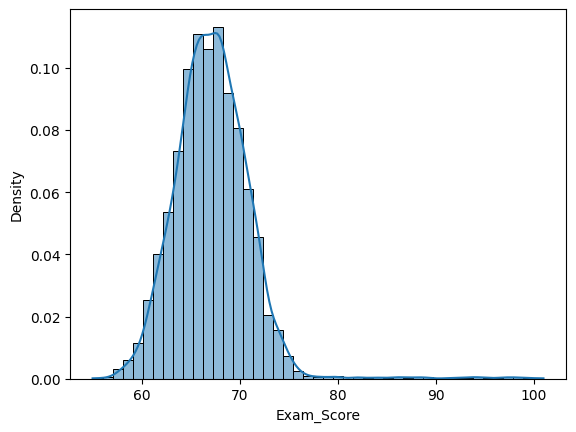

In [32]:
sns.histplot(df_copy['Exam_Score'], kde=True, stat="density", bins=45)

print('Асимметрия (Skewness): {:.4f}'.format(df_copy['Exam_Score'].skew()) )
print('Эксцесс (Kurtosis): {:.4f}'.format(df_copy['Exam_Score'].kurt()))
print('Межквартильная широта: {:.4f}'.format((df_copy['Exam_Score'].quantile(0.75) - df['Exam_Score'].quantile(0.25))/2))
print('Децильное отношение: {:.4f}'.format(df_copy['Exam_Score'].quantile(0.9)/df['Exam_Score'].quantile(0.1)))

Зависимая переменная имеет распределение близкое к нормальному с сильной правосторонней асимметрией и очень сильным пиком. Межквартильная широта 2, и децильное отношение ~1 говорит о небольшом разбросе данных. Мы логарифмируем зависимую переменную чтобы сжать длинный хвост, и сделать связи более линейными.

In [47]:
df_copy['Log_Exam_Score'] = np.log1p(df_copy['Log_Exam_Score'])

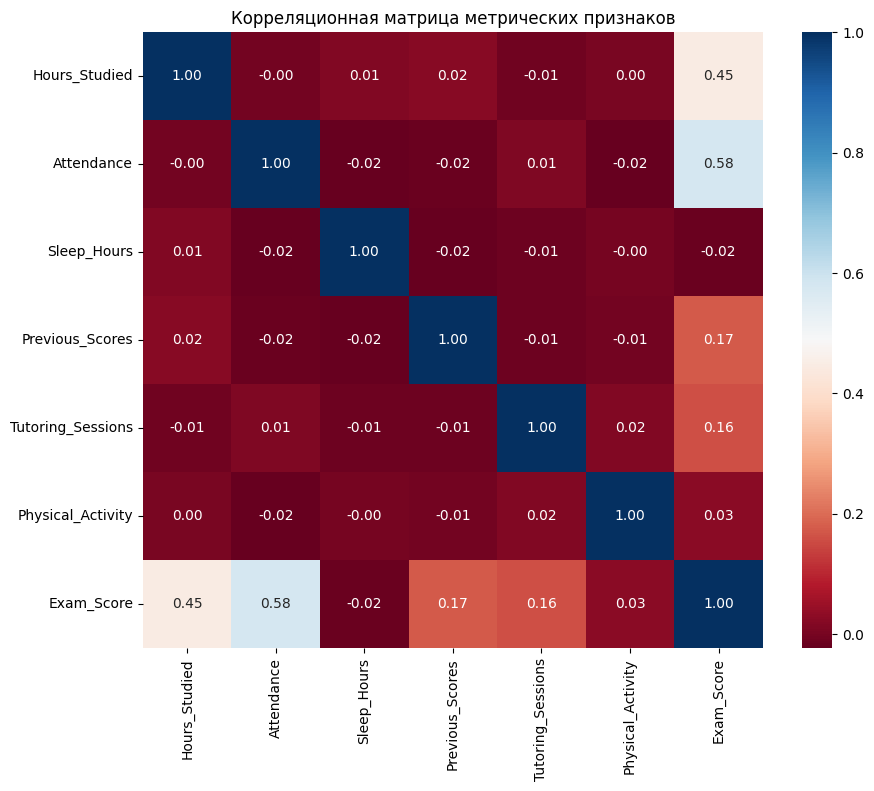

In [40]:
metric_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
plt.figure(figsize=(10, 8))
sns.heatmap(df_copy[metric_features].corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title("Корреляционная матрица метрических признаков")
plt.show()

По коэффициенту Пирсона в метрических переменных нет сильной корреляции, каждая из них подходит для линейной регрессии. Однако наблюдается весьма хорошая связь Hours_Studied, Attendance к зависимой переменной Exam_Score. Последним метрическим параметром выберем Previous_Scores так как он имеет наибольшую, пускай и слабую, связь.

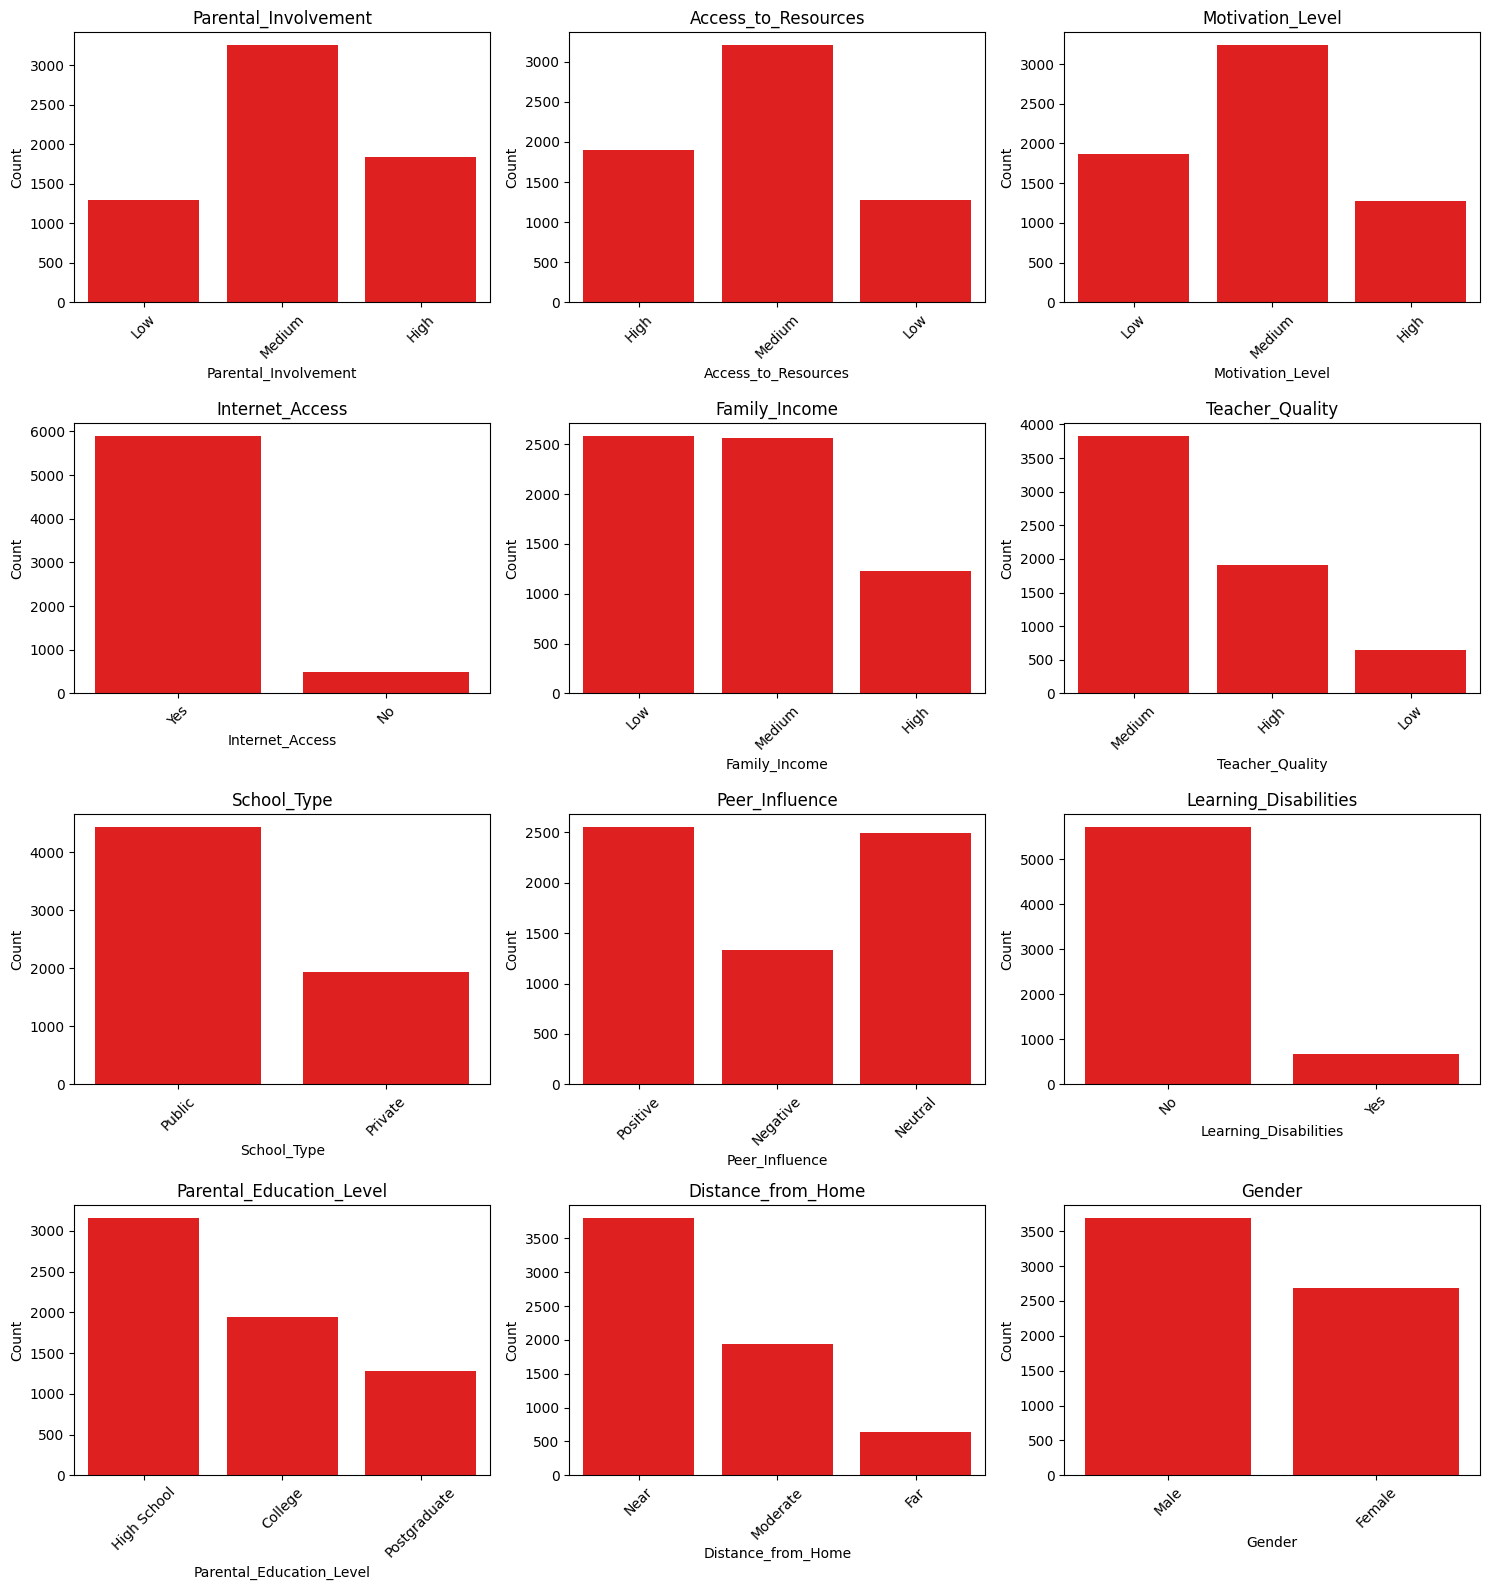

In [66]:

cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
            'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type',
            'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level',
            'Distance_from_Home', 'Gender']
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(x=col, data=df_copy, color="Red")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [67]:
for t in cat_cols:
  print(df_copy.groupby(t)['Exam_Score'].mean(), '\n')

Parental_Involvement
High      68.112200
Low       66.378776
Medium    67.113196
Name: Exam_Score, dtype: float64 

Access_to_Resources
High      68.103158
Low       66.223705
Medium    67.156367
Name: Exam_Score, dtype: float64 

Motivation_Level
High      67.743931
Low       66.764485
Medium    67.338894
Name: Exam_Score, dtype: float64 

Internet_Access
No     66.554639
Yes    67.309520
Name: Exam_Score, dtype: float64 

Family_Income
High      67.841463
Low       66.853215
Medium    67.371005
Name: Exam_Score, dtype: float64 

Teacher_Quality
High      67.681890
Low       66.775889
Medium    67.118662
Name: Exam_Score, dtype: float64 

School_Type
Private    67.316358
Public     67.223951
Name: Exam_Score, dtype: float64 

Peer_Influence
Negative    66.582707
Neutral     67.215631
Positive    67.636506
Name: Exam_Score, dtype: float64 

Learning_Disabilities
No     67.364448
Yes    66.291916
Name: Exam_Score, dtype: float64 

Parental_Education_Level
College         67.358432
High 

В данных не выявлено сильных статистически значимых параметров, поэтому при выборе параметров будем делать акцент на логических рассуждениях о показателях. При построении линейной регрессии возьмем параметры охватывающие разные аспекты жизни студента. Motivation_Level (мотивация студентов), Teacher_Quality (качество образования), Access_to_Resources (материально-техническая база)

In [93]:
cat_cols = ['Teacher_Quality', 'Access_to_Resources', 'Motivation_Level']

df_final = df_copy[['Log_Exam_Score','Teacher_Quality','Access_to_Resources','Motivation_Level', 'Hours_Studied', 'Attendance','Previous_Scores']]

df_final = pd.get_dummies(df_final, columns=cat_cols, drop_first=True, dtype=int)

df_final.head()

,Log_Exam_Score,Hours_Studied,Attendance,Previous_Scores,Teacher_Quality_Low,Teacher_Quality_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Motivation_Level_Low,Motivation_Level_Medium
0,1.652403,23,84,73,0,1,0,0,1,0
1,1.634547,19,64,59,0,1,0,1,1,0
2,1.671001,24,98,91,0,1,0,1,0,1
3,1.663294,29,89,98,0,1,0,1,0,1
4,1.660640,19,92,65,0,0,0,1,0,1


In [87]:
X = df_final.drop('Log_Exam_Score', axis=1)
y = df_final['Log_Exam_Score']

In [90]:
X_vif = sm.add_constant(X) # "Нулевая" точка отсчета для статистической модели

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

                      feature        VIF
0                       const  97.019986
1               Hours_Studied   1.001209
2                  Attendance   1.000700
3             Previous_Scores   1.003174
4         Teacher_Quality_Low   1.206309
5      Teacher_Quality_Medium   1.205039
6     Access_to_Resources_Low   1.338805
7  Access_to_Resources_Medium   1.337360
8        Motivation_Level_Low   1.742750
9     Motivation_Level_Medium   1.743413


# Общий вывод

Данный датасет отличается низкой взаимосвязью между своими параметрами, исходя из этого в данном задании, вместо того что бы действовать методом исключения устраняя схожие параметры имеющие высокую корреляцию между друг другом, я пошел методом выбора параметров имеющие наибольшую логическую связь и охватывающие разные спектры модели.

### Метрические параметры:
На основе корреляционной матрицы были отобраны три наиболее значимых количественных показателя: Attendance (Посещаемость), Hours_Studied (Часы обучения) и Previous_Scores (Предыдущие баллы).

Эти метрические параметры были выбраны из-за высокой корреляции с зависимой переменной, и низкой корреляцией между друг другом.

### Категориальные параметры:
Так как статистические методы (корреляция Пирсона) не применимы к тексту, выбор был сделан на основе логического охвата разных сфер жизни студента: Motivation_Level (Уровень мотивации), Teacher_Quality (Качество преподавания), Access_to_Resources (Доступ к ресурсам)

Для подтверждения чистоты данных был рассчитан VIF (Variance Inflation Factor). Для всех выбранных факторов VIF составил от 1.01 до 1.74, что значительно ниже критического порога (5.0). Это математически доказывает, что в нашей модели отсутствует мультиколлинеарность, а значит, полученные в дальнейшем коэффициенты будут устойчивыми и интерпретируемыми. Добавление константы (add_constant) на этом этапе позволило учесть базовый уровень баллов и корректно рассчитать взаимосвязи.

2. Постройте модель множественной линейной регрессии использовав в качестве предикторов исходные метрические переменные или рассчитанные на их основе компоненты и категориальные предикторы. Напишите уравнение регрессии. Оцените характеристики регрессионной модели в целом.

In [92]:
model = sm.OLS(y, X_vif).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Log_Exam_Score   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     1413.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:55:00   Log-Likelihood:                 23469.
No. Observations:                6378   AIC:                        -4.692e+04
Df Residuals:                    6368   BIC:                        -4.685e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

# Вывод

 Adj. R-squared: 0.666 - модель объясняет 66% процентов вариации логарифма экзаменационного балла.
 Prob (F-statistic): 0.00 - модель статистически значимая

### Уравнение регрессии
```math
ln(Score) = 1.5869
            + 0.0008 * Hours + 0.0006 * Attend + 0.0001 * Prev_Scores
            - 0.0030 * TQ_Low (or TQ_Med * 0.0015 or TQ_High * 0)
            - 0.0054 * AR_Low (or AR_Med * 0.0026 or AR_High * 0)
            - 0.0030 * ML_Low (or ML_Med * 0.0015 or ML_High * 0)
```
Константа (1.5869): Отражает базовый уровень логарифма балла для эталонного студента (с высоким уровнем качества обучения, ресурсов и мотивации) при нулевых значениях остальных факторов.

#### Положительные предикторы:

Наибольшее влияние среди количественных переменных оказывают часы обучения (0.0008) и посещаемость (0.0006). Рост этих показателей ведет к росту итогового балла.

#### Отрицательные предикторы (Качественные факторы):

Все коэффициенты при уровнях Low и Medium имеют отрицательный знак. Это подтверждает, что снижение качества преподавания, мотивации или доступа к ресурсам снижает итоговый балл относительно базового уровня (High). Наибольшее сильное негативное влияние оказывает отсутствие доступа к ресурсам (Access_to_Resources_Low: -0.0054).

### Диагностика остатков

Автокорреляция (Durbin-Watson = 1.997): Значение близко к 2.0, что свидетельствует об отсутствии автокорреляции в остатках.

Распределение (Omnibus/Jarque-Bera): Высокие значения тестов указывают на отклонение распределения остатков от нормального (высокий эксцесс и асимметрия). Предположительно это связано с большими хвостами в данных, чье поведение не удается предсказать данной моделью. Хоть мы и попытались сжать хвосты используя логарифм зависимой переменной, этого оказалось не достаточно что бы избавиться от статистических ошибок модели.

3. Оцените статистическую значимость регрессионных коэффициентов. Сравните их между собой по силе взаимосвязи с зависимой переменной. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной. Это очень важный пункт задания. Именно в нем мы узнаем, как именно каждый из предикторов взаимосвязан с зависимой переменной и какое изменение значений зависимой переменной можно ожидать при изменении значения предиктора на единицу.

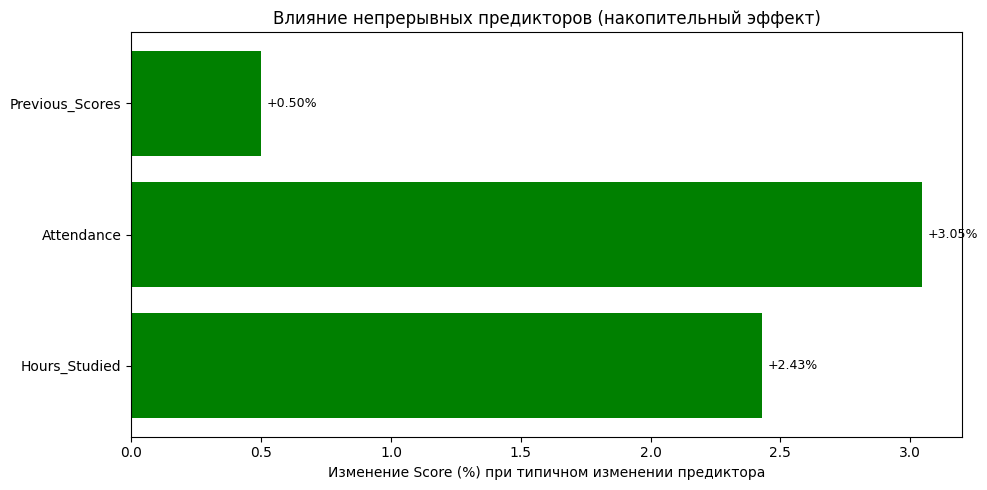

Непрерывные предикторы — эффект на типичное изменение:
        feature  typical_effect_pct   unit
  Hours_Studied            2.429032  часов
     Attendance            3.045453      %
Previous_Scores            0.501252 баллов


In [95]:
# Коэффициенты для непрерывных переменных
continuous = {
    'Hours_Studied': {'coef': 0.0008, 'range': (0, 60), 'unit': 'часов'},
    'Attendance': {'coef': 0.0006, 'range': (0, 100), 'unit': '%'},
    'Previous_Scores': {'coef': 0.0001, 'range': (0, 100), 'unit': 'баллов'}
}

# Считаем эффект на всём диапазоне и на типичном изменении (25-75 перцентиль)
data = []
for name, info in continuous.items():
    full_effect = info['coef'] * (info['range'][1] - info['range'][0])  # полный диапазон
    typical_change = (info['range'][1] - info['range'][0]) * 0.5  # условно половина диапазона
    typical_effect = info['coef'] * typical_change
    data.append({
        'feature': name,
        'coef': info['coef'],
        'full_effect_pct': (np.exp(full_effect) - 1) * 100,
        'typical_effect_pct': (np.exp(typical_effect) - 1) * 100,
        'unit': info['unit']
    })

df_cont = pd.DataFrame(data)

# Визуализация: эффект на "типичное" изменение
plt.figure(figsize=(10, 5))
bars = plt.barh(df_cont['feature'], df_cont['typical_effect_pct'],
                color=['green' if x > 0 else 'red' for x in df_cont['typical_effect_pct']])
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Изменение Score (%) при типичном изменении предиктора')
plt.title('Влияние непрерывных предикторов (накопительный эффект)')

# Подписи на столбцах
for bar, row in zip(bars, df_cont.itertuples()):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{row.typical_effect_pct:+.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Таблица для отчёта
print("Непрерывные предикторы — эффект на типичное изменение:")
print(df_cont[['feature', 'typical_effect_pct', 'unit']].to_string(index=False))

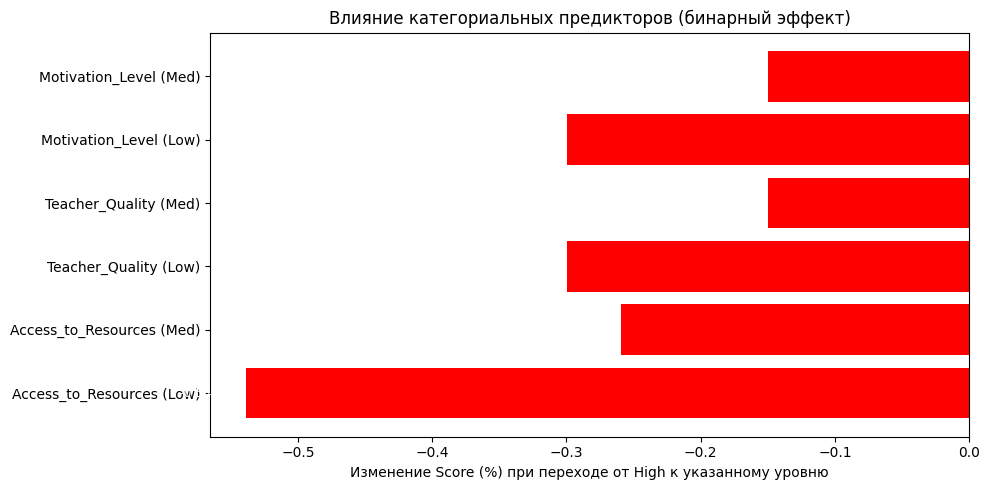


Категориальные предикторы — эффект перехода от High к указанному уровню:
                  feature  effect_pct
Access_to_Resources (Low)   -0.538545
Access_to_Resources (Med)   -0.259662
    Teacher_Quality (Low)   -0.299550
    Teacher_Quality (Med)   -0.149888
   Motivation_Level (Low)   -0.299550
   Motivation_Level (Med)   -0.149888


In [96]:
# Коэффициенты для категориальных переменных (dummy)
categorical = {
    'Access_to_Resources_Low': {'coef': -0.0054, 'group': 'Resources'},
    'Access_to_Resources_Medium': {'coef': -0.0026, 'group': 'Resources'},
    'Teacher_Quality_Low': {'coef': -0.0030, 'group': 'Teacher'},
    'Teacher_Quality_Medium': {'coef': -0.0015, 'group': 'Teacher'},
    'Motivation_Level_Low': {'coef': -0.0030, 'group': 'Motivation'},
    'Motivation_Level_Medium': {'coef': -0.0015, 'group': 'Motivation'}
}

# Считаем процентный эффект: (exp(β) - 1) × 100%
data_cat = []
for name, info in categorical.items():
    effect_pct = (np.exp(info['coef']) - 1) * 100
    data_cat.append({
        'feature': name.replace('_Low', ' (Low)').replace('_Medium', ' (Med)'),
        'group': info['group'],
        'coef': info['coef'],
        'effect_pct': effect_pct
    })

df_cat = pd.DataFrame(data_cat)

# Визуализация
plt.figure(figsize=(10, 5))
colors = ['red' if x < 0 else 'green' for x in df_cat['effect_pct']]
bars = plt.barh(df_cat['feature'], df_cat['effect_pct'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Изменение Score (%) при переходе от High к указанному уровню')
plt.title('Влияние категориальных предикторов (бинарный эффект)')

# Подписи
for bar, row in zip(bars, df_cat.itertuples()):
    plt.text(bar.get_width() - 0.05 if row.effect_pct < 0 else bar.get_width() + 0.02,
             bar.get_y() + bar.get_height()/2,
             f'{row.effect_pct:+.2f}%', va='center', fontsize=9,
             color='white' if row.effect_pct < 0 else 'black')

plt.tight_layout()
plt.show()

# Таблица для отчёта
print("\nКатегориальные предикторы — эффект перехода от High к указанному уровню:")
print(df_cat[['feature', 'effect_pct']].to_string(index=False))

# Анализ статистической значимости регрессионных коэффициентов

***P-value*** - каждого предиктора имеет ~ 0 значение, все коэффициенты статистически значимы для модели.

***t - статистическая устойчивость (по важности для модели)***
| Ранг | Предиктор | t |
|------|-----------|-----|
| 1 | Attendance | 84.715 |
| 2 | Hours_Studied | 64.343 |
| 3 | Access_to_Resources_Low | 24.488 |
| 4 | Previous_Scores | 24.285 |
| 5 | Access_to_Resources_Medium | 14.662 |
| 6 | Motivation_Level_Low | 13.437 |
| 7 | Teacher_Quality_Low | 10.818 |
| 8 | Teacher_Quality_Medium | 8.842 |
| 9 | Motivation_Level_Medium | 7.295 |


***Подробная интерпретация (Эффект на единицу)***

**Количественные параметры:**

- Hours_Studied (0.0008): При увеличении времени учебы на 1 час, ожидаемый балл студента вырастет на 0.08%.  

- Attendance (0.0006): При росте посещаемости на 1%, балл вырастет на 0.06%.  
  Смысл: условно говоря - студент, который ходит на 100% занятий, будет иметь балл на 6% выше, чем тот, кто не ходил вовсе (при прочих равных).

- Previous_Scores (0.0001): Каждый балл в прошлом дает 0.01% в настоящем. (P.S.: Ожидаемо, оценки в прошлом скорее показывают отношение студента к учебе в будущем, но навряд ли является самостоятельным фактором, в этом отношении возможно, использовать эту переменную было не лучшее решение, она фактически отражает все параметры просто на прошлой оценке)

**Категориальные параметры (сравнение с базой High):**

- Access_to_Resources (Ресурсы):  
  Уровень Low (-0.0054): Студент с плохими ресурсами получит балл на 0.54% ниже, чем студент с отличными ресурсами.
  Уровень Medium (-0.0026): Средние ресурсы снижают балл на 0.26% в сравнении с эталонным High.

- Teacher_Quality (Учитель):  
  Уровень Low (-0.0030): Слабый учитель снижает балл на 0.30%.  
  Уровень Medium (-0.0015): Средний учитель - на 0.15%.

- Motivation_Level (Мотивация):  
  Уровень Low (-0.0030): Низкая мотивация бьет по оценке так же сильно, как плохой учитель -0.30%.
  Уровень Medium (-0.0015): Средний уровень мотивации, так же дает -0.15% штрафа.

  ### Вывод
  Наибольшее влияние, на студента, оказывает Hours_Studied, Attendance и Access_to_Resources (иначе: дисциплина и доступ к ресурсам). Модель показала предсказуемый результат: доступ к ресурсам зачастую важнее личных стараний и мотивации. Отрицательные коэффициенты качественных переменных показывают статистически значимое снижение итогового балла.


  ***P.S.:*** В данной части работы я вывел две таблицы статистически значимых признаков по коэффициентам так как данная модель имеет сильное различие между параметрами категориальных и метрических признаков. И по сути делать сравнение между ними в одной таблице было бы не совсем корректно и не отражало бы сути их влияния на саму модель. (это же отображается в предупреждении от OLS про condition number).

4. Проведите диагностику модели. Оцените распределение остатков. Наблюдается ли гетероскедастичность, если да, то на основе чего сделан такой вывод? Сколько в модели выбросов и/или влияющих наблюдений?

In [99]:
names = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test = het_breuschpagan(model.resid, model.model.exog)

print(dict(zip(names, test)))

{'Lagrange multiplier statistic': np.float64(6.870398807006611), 'p-value': np.float64(0.6506107311930149), 'f-value': np.float64(0.7630026618623127), 'f p-value': np.float64(0.6509544669747205)}


Тест Бройша-Пагана показывает значение p-value ~ 0.65 > 0.05 не отвергаем нулевую гипотезу (отсутствие проблем). Это значит, что модель одинаково точна для студентов с разными прогнозируемыми баллами, и все статистические выводы являются корректными.

In [100]:
# Расчет расстояния Кука
influence = model.get_influence()
cooks = influence.cooks_distance[0]

# Порог (4 / количество строк)
n = len(df_final)
threshold = 4 / n

outliers = np.where(cooks > threshold)[0]
print(f"Количество влияющих наблюдений (по Куку): {len(outliers)}")
print(f"Процент выбросов: {len(outliers) / n * 100:.2f}%")

Количество влияющих наблюдений (по Куку): 75
Процент выбросов: 1.18%


### Диагностика влияющих наблюдений

**Метод:** Расстояние Кука (Cook's Distance)  
**Порог:** 4/n = 0.00063 (для n = 6378)  

**Результаты:**
- Выявлено 75 наблюдений с Dᵢ > порога (1.18% выборки)
- Ни одно наблюдение не превышает экстремальный порог Dᵢ > 1.0

**Интерпретация:**
- Процент влияющих точек находится в ожидаемом диапазоне (0.5–2%) для случайных данных
- Модель демонстрирует устойчивость: коэффициенты не зависят от отдельных наблюдений
- Дополнительная очистка данных не требуется

**Вывод:** Результаты регрессии надёжны и могут быть обобщены на всю популяцию студентов.

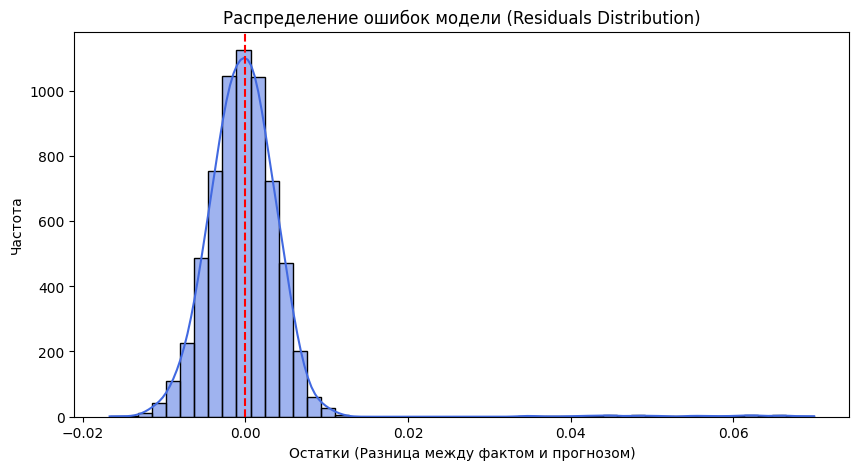

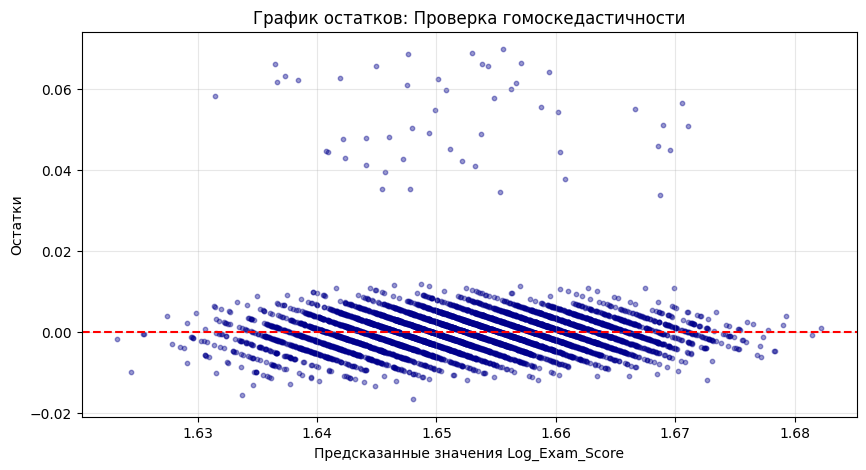

In [102]:
y_pred = model.predict(X_vif)
residuals = model.resid

# --- График 1: Гистограмма остатков ---
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color='royalblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Остатки (Разница между фактом и прогнозом)")
plt.ylabel("Частота")
plt.title("Распределение ошибок модели (Residuals Distribution)")
plt.show()

# --- График 2: График остатков (Homoscedasticity Check) ---
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color='darkblue', s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения Log_Exam_Score")
plt.ylabel("Остатки")
plt.title("График остатков: Проверка гомоскедастичности")
plt.grid(alpha=0.3)
plt.show()

#Вывод
Визуальный анализ остатков подтверждает хорошее качество модели. Гистограмма демонстрирует симметричное распределение с острой вершиной в нуле, что свидетельствует о несмещенности оценок. График рассеяния остатков подтверждает гомоскедастичность (постоянство дисперсии ошибок), что позволяет утверждать о статистической достоверности полученных коэффициентов регрессии. Выявленные ранее выбросы (1.18) визуализированны в виде еденичных точек в верхней части графиков и не оказывают сильного искажающего эффекта.

5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных. Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

# Общий вывод

На основе выборки из 6 378 наблюдений построена модель множественной линейной регрессии для прогнозирования экзаменационного балла студента. Зависимая переменная `Exam_Score` была логарифмирована для нормализации распределения. Построенная модель объясняет **66.6%** вариации учебных достижений студентов.

Данную модель можно принять как статистически надежную: в ней нет мультиколлинеарности (VIF < 1.8) и гетероскедастичности (p-value теста Бройша-Пагана = 0.65). Несмотря на то, что остатки распределены ненормально, отсутствие гетероскедастичности позволяет доверять модели.

### Ожидаемый результат
* **Прямая сильная связь между усилиями и результатом:** То, что `Hours_Studied` и `Attendance` имеют положительное влияние, было предсказуемо.
* **Штраф за «Low»-уровни:** Снижение качества обучения или доступа к ресурсам предсказуемо тянет итоговый балл вниз.

### Неочевидный результат
* **Доступ к ресурсам важнее мотивации:** Параметр `Access to Resources` (t = 24.5) оказался более значимым фактором, чем `Motivation Level` (t = 13.4).
* **Статистический парадокс эксцесса:** Выявлен гигантский эксцесс остатков (54.65) на фоне хорошего теста на гетероскедастичность (наличие небольшой доли "гениальных" выбросов, не ломающих общую дисперсию).
* **Слабость «прошлых заслуг»:** Прошлые успехи имеют очень слабое влияние, по сути являясь всего лишь "зеркалом" остальных параметров, смещенных на предыдущую оценку.

***P.S. (Методологическая рефлексия):*** Поскольку я уже был знаком с данным датасетом, то изначально ожидал, что влияние каждого из факторов на итоговую оценку будет незначительным, хотя и статистически значимым. Поэтому в этой работе я выбрал путь целенаправленного выбора параметров, объясняющих большую часть итоговой оценки, вместо метода исключения незначимых (таких там попросту не было, а их взаимосвязи друг с другом довольно слабы).

Также, учитывая особенность распределения оценок, я не стал удалять "выбросы". Вместо этого я прологарифмировал зависимую переменную, чтобы сохранить в модели "влияние" отличников, но при этом не дать им "перетянуть" на себя общую статистику.

Выбор `Previous_Scores` считаю ошибочным: параметр не оказал того влияния и не принес того смысла, который я изначально в него вкладывал, оказавшись эндогенным отражением других факторов.